# Comparaison d'algorithmes pour les MFGs monotones : cas potentiel et non potentiel

Un des objectifs de ce notebook est de valider les algorithmes Mirror-Prox (model-based, Algo 1–2 du rapport) et
Greedy-OMP (model-free) sur **deux régimes** :

| Régime | Noyau d'interaction $\kappa$ | Nature du problème | Algorithme suffisant |
|---|---|---|---|
| **Potentiel** | symétrique | $F = \nabla\Phi$, $\Phi$ convexe : **programme convexe** | Mirror Descent (= MD-CURL) |
| **Non potentiel** | partie antisymétrique $\neq 0$ | VI monotone | Mirror-**Prox** (extrapolation) |

**L'enjeu :** Toutes les expériences MFG classiques (congestion) sont dans le cas potentiel, où
l'équivalence MFG $\leftrightarrow$ CURL de Geist et al. s'applique : Mirror Descent suffit, et
Mirror-Prox n'apporte rien de plus, étant donné que dans le cas CURL, les travaux de Moreno et al. abordent en détail l'analyse théorique de MD dans le cas model-based et online. Un OMD a été proposé (cf Perolat 2022 - Scaling up ...) mais déjà c'est en temps continu ET en plus ça ne donne aucune garantie théorique. La justification de Mirror-Prox
n'apparaît que dans le cas **monotone non potentiel**, où l'opérateur a une composante
**rotationnelle**. Le seul "concurrent" potentiel de Mirror-Prox c'est APP (de l'article Last Iterate, ... de Isobe et al) mais il les garanties sont uniquement en model-based, ça se base sur du MD, il a 2 boucles,  3 hyperparam et toutes ses hypothèses ne sont pas folles si on veut passer à l'online donc le passage à l'online n'est pas forcément ce qu'il y a de mieux. En revanche notre Mirror-Prox peut très bien s'adapter, un hyperparam, une boucle, on peut facilement utiliser les résultats géométriques de Moreno et al. au moins pour une partie, et le passage à l'online est bcp plus crédible, ensuite l'algo MetaCURL nous permettra de gérer aussi l'extension dans laquelle notre noyau dépendra de $\mu$ chose qui n'a jamais été bien traité je crois en online pour les algos MFG CLASSIQUES (Zeng et al. l'a abordé vite fait dans un article avec la notion de Herding qu'il a introduite, son algo est Gradient-based, reste à voir comment ça se positionne par rapport aux algos classiques).


## Choix de notre type de récompense pour illustrer les deux cas : potentiel et non potentiel

En repartant de l'hypothèse de séparabilité directement, $r'_h(s, \mu)$ est un scalaire, c'est la part de récompense, due à la foule, que touche un agent situé en $s$ quand la population est répartie selon $\mu$. 
Ici $\mu \in \mathbb{R}^{|\mathcal{S}|}$ est un vecteur, $\mu(s')$ étant la fraction de la population en $s'$.

Si on veut $r'_h(s, \cdot)$ **affine** en $\mu$ (un régime qui nous permet déjà de voir des choses et qui englobe pas mal d'exemple classiques), la forme la plus générale est : 
$$ r'_h(s, \mu) = \sum_{s' \in \mathcal{S}} \kappa_h(s, s')\mu(s') + c_h(s) = \langle \kappa(s, \cdot), \mu \rangle + c_h(s) \ .$$
Donc $\kappa_h$ est une **matrice** de taille $|\mathcal{S}| \times |\mathcal{S}|$, et il faut bien distinguer deux indices : 
- $s$ : où est l'agent (le 1er indice, fixé)
- $s'$ : où est la foule (le 2e indice sur lequel on somme).

De cette manière, $\kappa_h(s, \cdot) \in \mathbb{R}^{|\mathcal{S}|}$ s'interprète comme un profil de sensibilité : comment l'agent réagit à la foule partout.

On peut donner deux exemples de choix de $\kappa$ pour illustrer les deux régimes (potentiel/non potentiel), en liant ces régimes à la symétrie de $\kappa$ (nous précisons ces liens dessous): 
| Modèle | $\kappa_h(s, s')$ | Symétrique ? |
|---|---|---|
| **Congestion pure** | $-c$ si $s' = s$, $0$ sinon, i.e. $\kappa = -c\text{Id}$ | Oui | 
| **Congestion cyclique** | $w$ si $s'$ est dans la pièce suivante, $-w$ si précédente | Non | 

Dans le 1er cas, seule la foule à la position de l'agent compte, alors que dans le second, l'agent est pénalisé par la foule ailleurs, et sans réciprocité.




On peut donc donner l'expression suivante pour la récompense qui comprend les deux régimes et dont la congestion cyclique est contrôlée par le paramètre $w$, la récompense séparable (A.4, nous omettons le terme dépendant de $a$ pour l'instant) et affine (A.6) est :
$$r_h(s,a,\mu) = \langle \kappa(s,\cdot), \mu_h \rangle, \qquad
\kappa = \underbrace{-c\,\mathrm{Id}}_{\text{symétrique}} + \underbrace{w\,(C - C^\top)}_{\text{antisymétrique}},$$
où $C$ encode une **congestion cyclique** entre les quatre pièces : la pièce $i$ est pénalisée par la
foule présente dans la pièce $\sigma(i)$, **sans réciprocité** (structure pierre-feuille-ciseaux).

Concernant les deux propriétés clés qui seront vérifiées numériquement plus bas :
- **Lasry-Lions (A.5) tient pour tout $w$** : la forme quadratique ne voit que la partie symétrique,
  $\langle \kappa x, x\rangle = \langle \kappa^{\mathrm{sym}} x, x\rangle = -c\|x\|^2 \leqslant 0$.
  L'opérateur $F$ est donc **monotone** dans les deux régimes, et toute l'analyse théorique du
  rapport s'applique.
- **$F$ dérive d'un potentiel $\iff \kappa$ symétrique $\iff w = 0$** (fait détaillé dans la section suivante). En effet la jacobienne de $F$
  vaut $-H\,\kappa(s,s')\,\mathbf{1}\{h = h'\}$, symétrique si et seulement si $\kappa$ l'est.

Détaillons le calcul de la Jacobienne. $F$ va de $\mathbb{R}^{H \times | \mathcal{S}| \times |\mathcal{A}|}$ dans lui-même. Sa Jacobienne est donc définie de la manière suivante : 
$$ J[(h, s, a), (h', s', a')] := \frac{\partial F(d)(h, s, a)}{\partial d(h', s', a')} \ .$$
On peut tout d'abord écrire : 
$$ F(d)(h, s, a) = -\langle \kappa_h(s, \cdot), \mu_h^d \rangle - c_h(s) - r''_h(s, a) \ ,$$
seul le premier terme dépend de $d$. Avec $\mu^d_h(s'') = H\sum_{a''} d(h, s'', a'')$ :
$$ \frac{\partial \mu_h^d(s'')}{\partial d(h', s', a')} = H\mathbf{1}\{h = h'\}\mathbf{1}\{s'' = s'\} \ ,$$
d'où, 
$$ J[(h, s, a), (h', s', a')] = -H\kappa_h(s, s')\mathbf{1}\{h = h'\} \ .$$

## Un point pour savoir quand $F$ dérive-t-il d'un potentiel (convexe ou pas) ou non dans le cas affine

Notre opérateur s'écrit $F(d) = Md + b$ (cas particulier : affine en $d$). On décompose $M$ en parties
symétrique et antisymétrique et nous énonçons ensuite quelques résultats:

$$
M = S + A, \qquad S = \tfrac{1}{2}(M + M^\top), \qquad A = \tfrac{1}{2}(M - M^\top).
$$



Soit $F(d) = Md + b$ sur $\mathbb{R}^n$. Alors :

**(i) Potentialité $\iff$ partie symétrique.**
$$
\begin{cases}
  &F = \nabla\Phi \ \text{ sur } \mathbb{R}^n  \ , \\
  &\Phi(d) = \tfrac{1}{2}\langle M d, d\rangle + \langle b, d\rangle, \quad \text{(à constante près)}\\
  &\nabla\Phi(d) = \tfrac{1}{2}(M + M^\top)d + b.
\end{cases}, 
\iff M = M^\top \ (\text{i.e. } A = 0)$$

**(ii) Monotonie $\iff$ partie symétrique (uniquement).**
$$
F \text{ monotone} \iff S \succeq 0.
$$

**(iii) Convexité du potentiel $\iff$ semi-définie positive.**
$$
\Phi \text{ convexe} \iff S \succeq 0.
$$

**(iv) $F$ dérive d'un potentiel convexe $\iff$ symétrique ET semi-définie positive.**
$$
F \ \text{dérive d'un potentiel convexe} \iff M = M^T \ \text{et} \ M \succeq 0 \ .
$$

#### Preuve

**(i)** On a $\nabla\Phi(d) = \tfrac{1}{2}(M + M^\top)d + b$, qui égale $Md + b = F(d)$ pour tout $d$
si et seulement si $\tfrac{1}{2}(M + M^\top) = M$, i.e. $M = M^\top$. Réciproquement, la jacobienne
d'un gradient est toujours symétrique (Schwarz). Comme $M$ est **constante**, l'énoncé est global sur $\mathbb{R}^n$ et ne
requiert aucune hypothèse topologique.

**(ii)** Pour $z = x - y$, $\langle F(x) - F(y), x - y\rangle = \langle M z, z\rangle$. Or
$\langle A z, z\rangle = 0$ pour toute matrice antisymétrique, donc
$\langle M z, z\rangle = \langle S z, z\rangle$. La monotonie ($\geq 0$ pour tout $z$) équivaut donc
à $S \succeq 0$ : **elle ne voit que la partie symétrique**.

## Application à notre noyau $\kappa$

On a vu que la jacobienne valait
$$
J[(h,s,a),(h',s',a')] = -H\,\kappa_h(s,s')\,\mathbf{1}\{h = h'\},
$$
constante en $(a, a')$ : le facteur sur les actions est un bloc $\mathbf{1}\mathbf{1}^\top$ symétrique,
qui n'affecte pas la symétrie de $J$. On peut réutiliser les faits ci-dessus avec $M = J$ puisque pour $F(d) = Md + b$, on remarque que $M = J$. Donc

$$
J = J^\top
\iff \kappa_h(s,s') = \kappa_h(s',s)
\iff \kappa \text{ symétrique}
\iff \kappa^{\mathrm{antisym}} = 0.
$$

Avec $\kappa = \underbrace{-c\,\mathrm{Id}}_{\text{symétrique}} + \underbrace{w\,(C - C^\top)}_{\text{antisymétrique}}$,
la partie antisymétrique est $w\,(C - C^\top)$.

En conclusion, on a pour les deux régimes :

- **Cas $\kappa = -c\,\mathrm{Id}$ (potentiel).** $\kappa$ est symétrique $\Rightarrow J = J^\top
  \Rightarrow F = \nabla\Phi$. De plus $S = -H\,\kappa^{\mathrm{sym}} = Hc\,\mathrm{Id} \succeq 0$
  (avec $c, H > 0$), donc $\Phi$ est **convexe** : c'est un **programme convexe**, et Mirror Descent
  suffit.

- **Cas $\kappa = -c\,\mathrm{Id} + w\,(C - C^\top)$ avec $w \neq 0$ (non potentiel).** La partie
  antisymétrique $w\,(C - C^\top)$ est non nulle (voir réserve ci-dessous) $\Rightarrow J \neq J^\top
  \Rightarrow F$ **ne dérive d'aucun potentiel**. L'opérateur reste monotone (VI monotone
  **rotationnelle**), ce qui justifie l'extrapolation de Mirror-Prox.

Un point à garder en tête :

Ce n'est pas $w \neq 0$ seul qui casse la potentialité, mais $w\,(C - C^\top) \neq 0$. La condition
exacte est :
$$
F \text{ dérive d'un potentiel}
\iff \kappa^{\mathrm{antisym}} = 0
\iff w\,(C - C^\top) = 0.
$$
Si l'on choisissait $C$ **symétrique**, alors $C - C^\top = 0$ et $\kappa$ resterait symétrique quel
que soit $w$ (on n'aurait jamais quitté le cas potentiel). Dans notre construction, $C$ encode une
congestion cyclique **sans réciprocité** (structure pierre-feuille-ciseaux), donc $C - C^\top \neq 0$
par design, et les deux conditions coïncident :
$$
F \text{ dérive d'un potentiel} \iff w = 0.
$$

Par ailleurs, la convexité de $\Phi$ dans le cas potentiel n'est pas une hypothèse supplémentaire : comme
$S = Hc\,\mathrm{Id} \succeq 0$ dans **tous** les régimes (c'est la monotonie / Lasry-Lions), dès que
$w = 0$ on a $M = S \succeq 0$, donc $\Phi$ convexe automatiquement. Autrement dit,
$$
\underbrace{S \succeq 0 \ \text{(partout)}}_{\text{monotonie}}
\ + \
\underbrace{A = 0 \ \text{(quand } w = 0)}_{\text{potentialité}}
\ \Longrightarrow \
\text{programme convexe.}
$$

In [1]:
import numpy as np
from scipy.special import logsumexp, softmax
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
ACTIONS = np.array([(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)])

def build_four_room(n=11):
    mid = n // 2
    doors = {(mid, 2), (mid, n - 3), (2, mid), (n - 3, mid)}
    blocked = set()
    for c in range(n):
        if (mid, c) not in doors: blocked.add((mid, c))
    for r in range(n):
        if (r, mid) not in doors: blocked.add((r, mid))
    cells = [(r, c) for r in range(n) for c in range(n) if (r, c) not in blocked]
    cell_to_idx = {cell: i for i, cell in enumerate(cells)}
    coords = np.array(cells)
    nS, nA = len(cells), len(ACTIONS)
    step_idx = np.zeros((nS, nA), dtype=int)          # g : deplacement deterministe
    for s, (r, c) in enumerate(cells):
        for a in range(nA):
            dr, dc = ACTIONS[a]
            step_idx[s, a] = cell_to_idx.get((r + dr, c + dc), s)
    room = np.array([(0 if r < mid else 2) + (0 if c < mid else 1) for r, c in cells]) # pour s'assurer qu'on reste bien dans la grille
    return step_idx, coords, cell_to_idx, (n, n), room

def true_noise_dist(slip, nA):
    h = np.full(nA + 1, slip / nA); h[nA] = 1.0 - slip   # ici c'est pour la dynamique inconnue du learner : s_{h + 1} = g(s, a, \epsilon)
    return h

def kernel_from_noise(h_noise, step_idx):
    nS, nA = step_idx.shape
    P = np.zeros((nA, nS, nS)); ss = np.arange(nS)
    for a in range(nA):
        np.add.at(P[a], (ss, step_idx[:, a]), h_noise[nA])
        for e in range(nA):
            np.add.at(P[a], (ss, step_idx[:, e]), h_noise[e])
    return P

step_idx, coords, c2i, grid_shape, room = build_four_room(11)
nS, nA = step_idx.shape
h_true = true_noise_dist(slip=0.05, nA=nA)
P_true = kernel_from_noise(h_true, step_idx)
xi = np.zeros(nS); xi[c2i[(0, 0)]] = 1.0
print(f"nS={nS} | nA={nA} | tailles des 4 pieces : {[int((room==i).sum()) for i in range(4)]}")

nS=104 | nA=5 | tailles des 4 pieces : [25, 26, 26, 27]


### Le noyau d'interaction $\kappa$ et vérifications sur la symétrie

$C(s,s') = 1/|\text{pièce}|$ si $s'$ est dans la pièce $\sigma(\text{pièce}(s))$ — la moyenne du flot
de la pièce cible. La partie antisymétrique $w(C - C^\top)$ crée le cycle sans réciprocité.

In [7]:
CYCLE = {0: 1, 1: 3, 3: 2, 2: 0}      # cycle sur les 4 pieces (haut-G -> haut-D -> bas-D -> bas-G)

def build_kappa(room, c_cong=1.0, w_cyc=0.0):
    '''kappa = -c Id + w (C - C^T).'''
    nS = len(room)
    C = np.zeros((nS, nS))
    for s in range(nS):
        idx = np.where(room == CYCLE[room[s]])[0]
        C[s, idx] = 1.0 / len(idx)
    return -c_cong * np.eye(nS) + w_cyc * (C - C.T)

def make_reward(kappa, nA):
    '''r_h(s,a,mu) = <kappa(s,.), mu>  : separable (A.4) et affine (A.6).'''
    def reward(mu_h):
        return np.repeat((kappa @ mu_h)[:, None], nA, axis=1)
    return reward

def kappa_diagnostics(kappa):
    sym = 0.5 * (kappa + kappa.T); anti = 0.5 * (kappa - kappa.T)
    return {'max_eig_sym': float(np.linalg.eigvalsh(sym).max()),      # <=0 <=> Lasry-Lions
            'norm_anti': float(np.linalg.norm(anti)),
            'ratio_anti_sym': float(np.linalg.norm(anti) / np.linalg.norm(sym))}

# --- les deux regimes
C_POT, W_POT = 1.0, 0.0        # potentiel   : kappa symetrique
C_NP,  W_NP  = 0.05, 5.0       # non potentiel : forte composante rotationnelle

kappa_pot = build_kappa(room, C_POT, W_POT)
kappa_np  = build_kappa(room, C_NP,  W_NP)
reward_pot = make_reward(kappa_pot, nA)
reward_np  = make_reward(kappa_np,  nA)

for lab, kap in [('POTENTIEL', kappa_pot), ('NON POTENTIEL', kappa_np)]:
    dg = kappa_diagnostics(kap)
    sym_err = np.abs(kap - kap.T).max()
    print(f"{lab:14s} | kappa symetrique : {sym_err < 1e-12} (ecart max {sym_err:.2f})"
          f" | Lasry-Lions (max vp sym <= 0) : {dg['max_eig_sym'] <= 1e-9}"
          f" (= {dg['max_eig_sym']:+.3f}) | ||anti||/||sym|| = {dg['ratio_anti_sym']:.2f}")

POTENTIEL      | kappa symetrique : True (ecart max 0.00) | Lasry-Lions (max vp sym <= 0) : True (= -1.000) | ||anti||/||sym|| = 0.00
NON POTENTIEL  | kappa symetrique : False (ecart max 0.40) | Lasry-Lions (max vp sym <= 0) : True (= -0.050) | ||anti||/||sym|| = 27.75


**Lecture.** Dans les deux cas la condition de Lasry-Lions est satisfaite (la plus grande valeur
propre de $\kappa^{\mathrm{sym}}$ est $\leqslant 0$), donc $F$ est monotone et toutes les hypothèses
(A.1)–(A.6) tiennent. Seule différence : le second $\kappa$ **n'est pas symétrique**, donc $F$ ne
dérive d'aucun potentiel et le problème n'est plus un programme convexe : c'est une VI.

## 2. Briques MFG (identiques aux notebooks précédents)

In [8]:
# Passer du champ moyen à l'occupation measure (pour la politique \pi jouée et le noyau P (connu ou estimé))
def forward_unroll(pi, P, xi, H):
    nS, nA = pi.shape[1], pi.shape[2]
    d = np.zeros((H, nS, nA)); bar = np.zeros((H, nS)); bar[0] = xi / H
    for h in range(H - 1):
        d[h] = bar[h][:, None] * pi[h]
        bar[h + 1] = np.einsum('sa,asx->x', d[h], P)
    d[H - 1] = bar[H - 1][:, None] * pi[H - 1]
    return d, bar

# Pour passer de d à \pi
def policy_of(d, eps=1e-12):
    bar = d.sum(axis=2)
    pi = d / np.maximum(bar[:, :, None], eps); pi[bar < eps] = 1.0 / d.shape[2]
    return pi

def prox_gamma(mu, d_ref, gam, P, xi, reward, eps=1e-12):
    '''Prox-Gamma (Algo 2) : backward soft-value + twist exponentiel, puis forward.'''
    H, nS, nA = d_ref.shape
    log_pi_ref = np.log(np.maximum(policy_of(d_ref, eps), eps))
    pi_new = np.zeros((H, nS, nA)); V = np.zeros(nS)
    for h in range(H - 1, -1, -1):
        Q = reward(mu[h]) + np.einsum('asx,x->sa', P, V)
        logits = log_pi_ref[h] + gam * Q
        V = logsumexp(logits, axis=1) / gam
        pi_new[h] = softmax(logits, axis=1)
    d_new, _ = forward_unroll(pi_new, P, xi, H)
    return d_new

Bellman d'optimalité pour la BR : 
$$ V_h^{\text{br}}(s) = \max_a \left[ r(s, a, \mu_h) + \sum_x P(x | s, a)V_{h + 1}^{\text{br}}(x) \right]$$
Le max sur les actions est ce qui définit la BR : à chaque état, l'agent choisit l'action optimale.

Bellman d'évaluation pour la politique courante : 
$$ V_h^{\pi}(s) = \sum_a \pi_h(a | s) \left[ r(s, a, \mu_h) + \sum_x P(x | s, a)V_{h + 1}^{\pi}(x) \right]$$ 
Au lieu de prendre un max : on fait une espérance sous la politique jouée.

In [9]:
def exploitability(d, P, xi, reward, eps=1e-12):
    H, nS, nA = d.shape
    mu = H * d.sum(axis=2); pi = policy_of(d, eps) # mu = champ moyen considéré et pi = politique induite par d
    V_br = np.zeros(nS); V_pi = np.zeros(nS) # V_br = valeur de la BR contre le champ moyen fixé et V_pi = valeur de la politique courante pi (induite par d) contre le même champ moyen
    for h in range(H - 1, -1, -1): # Passe backward
        r_h = reward(mu[h])
        V_br = (r_h + np.einsum('asx,x->sa', P, V_br)).max(axis=1)
        V_pi = (pi[h] * (r_h + np.einsum('asx,x->sa', P, V_pi))).sum(axis=1)
    return float(xi @ (V_br - V_pi))

def to_grid(vec, coords, shape):
    g = np.full(shape, np.nan)
    for i, (r, c) in enumerate(coords): g[r, c] = vec[i]
    return g

## 3. Les trois algorithmes comparés

| Algorithme | Origine | Coût / itération | Hyperparamètres |
|---|---|---|---|
| **Mirror Descent (MD)** | OMD-MFG (Pérolat et al.), MD-CURL (Moreno et al.) | 1 passe backward | $\gamma$ |
| **Mirror-Prox (MP)** | Algo 1 du rapport (Nemirovski) | **2** passes backward | $\gamma$ |
| **APP** | Isobe, Abe & Ariu (NeurIPS 2025) | 1 passe backward / pas interne | $\lambda, \eta, \tau$ |

MD et MP ne diffèrent que par le nombre de pas proximaux (un seul contre extrapolation +
correction). **APP** est un algorithme différent : une boucle externe de **point proximal** qui
ré-ancre une base $\sigma^k$, chaque mise à jour étant approchée par $\tau$ pas de **Mirror Descent
régularisé (RMD)** sur le MFG régularisé par KL. C'est, à notre connaissance, le seul autre
algorithme visant la convergence du **dernier itéré** sous monotonie **non stricte** — donc le vrai
concurrent de Mirror-Prox sur ce terrain.

**Comparaison à budget égal.** Les coûts par itération diffèrent ; toutes les figures ci-dessous
sont donc tracées en fonction du **nombre de passes backward** (l'opération dominante :
un calcul de $Q$ sur tout l'horizon), et non du nombre d'itérations.

In [10]:
def mirror_prox_mb(P, xi, reward, H, K, gam):
    '''Algo 1 du rapport : DEUX prox par iteration, meme reference d^k.'''
    nS, nA = P.shape[1], P.shape[0]
    d_k, _ = forward_unroll(np.full((H, nS, nA), 1.0 / nA), P, xi, H)
    ssum = np.zeros((H, nS, nA)); e_last, e_avg, mus = [], [], []
    for k in range(1, K + 1):
        mu_k = H * d_k.sum(axis=2)
        d_half = prox_gamma(mu_k, d_k, gam, P, xi, reward)          # extrapolation
        mu_half = H * d_half.sum(axis=2)
        d_k = prox_gamma(mu_half, d_k, gam, P, xi, reward)          # correction
        ssum += d_half
        e_last.append(exploitability(d_half, P, xi, reward))
        e_avg.append(exploitability(ssum / k, P, xi, reward))
        mus.append(mu_half.copy())
    return ssum / K, np.array(e_last), np.array(e_avg), np.array(mus)

def mirror_descent_mb(P, xi, reward, H, K, gam):
    '''MD-CURL / OMD pour MFG : UN SEUL prox par iteration.'''
    nS, nA = P.shape[1], P.shape[0]
    d_k, _ = forward_unroll(np.full((H, nS, nA), 1.0 / nA), P, xi, H)
    ssum = np.zeros((H, nS, nA)); e_last, e_avg, mus = [], [], []
    for k in range(1, K + 1):
        mu_k = H * d_k.sum(axis=2)
        d_k = prox_gamma(mu_k, d_k, gam, P, xi, reward)
        ssum += d_k
        e_last.append(exploitability(d_k, P, xi, reward))
        e_avg.append(exploitability(ssum / k, P, xi, reward))
        mus.append(mu_k.copy())
    return ssum / K, np.array(e_last), np.array(e_avg), np.array(mus)

### APP (Isobe, Abe & Ariu)

Règle RMD (leur éq. 4.4) :
$$\pi^{t+1}_h(a|s) \ \propto\ \sigma_h(a|s)^{\lambda\eta}\ \pi^t_h(a|s)^{1-\lambda\eta}\
\exp\!\big(\eta\, Q^{\lambda,\sigma}_h(s,a,\pi^t,\mu^t)\big),$$
où $Q^{\lambda,\sigma}$ est la Q-fonction **régularisée par KL** (leurs éq. 4.2–4.3) :
$$V^{\lambda,\sigma}_h(s) = \sum_a \pi_h(a|s) Q_h(s,a) - \lambda\, D_{\mathrm{KL}}\big(\pi_h(\cdot|s),\sigma_h(\cdot|s)\big),
\qquad Q^{\lambda,\sigma}_h(s,a) = r_h(s,a,\mu_h) + \sum_{s'} P_h(s'|s,a)\, V^{\lambda,\sigma}_{h+1}(s').$$
APP (leur Algorithme 1) enchaîne : $\sigma^{k+1} = \mathrm{RMD}(\sigma^k, \lambda, \eta, \tau)$ —
$\tau$ pas de RMD initialisés en $\sigma^k$ avec $\sigma^k$ pour base, puis ré-ancrage. Sans ce
ré-ancrage, on ne converge que vers l'équilibre *régularisé*, distant de $O(\lambda)$ de la cible.


### Un point sur le lien entre l'article et le code : 

Rappelons les définitions de l'article : 
$$
V_h^{\lambda, \sigma}(s) = \mathbb{E}_{(s_l, a_l)_{l \in \{h, ..., H \}}}\left[ \sum_{l = h}^H (r_l(s_l, a_l, \mu_l) - \lambda D_{\text{KL}}(\pi_l(s_l), \sigma_l(s_l)))\right], \quad V_{H + 1}^{\lambda, \sigma} \equiv 0 \\
Q_h^{\lambda, \sigma}(s, a) = r_h(s, a, \mu_h) + \mathbb{E}_{s' \sim P(s, a)}\left[ V_{h + 1}^{\lambda, \sigma} \right]
$$

Pour avoir une forme récursive dans le code, on peut sortir de $V_h$ le terme $l = h$, on obtient : 
$$
V_h^{\lambda, \sigma}(s) = \underbrace{\mathbb{E}_{a \sim \pi_h(s)}[r_h(s, a, \mu_h)]}_{ \text{récompense au temps $h$}} - \lambda D_{\text{KL}}(\pi_h(s), \sigma_h(s)) + \underbrace{\mathbb{E}_{a \sim \pi_h(s), s' \sim P(s, a)}[V_{h + 1}^{\lambda, \sigma}(s')]}_{ \text{reste de la trajectoire}} \ .
$$
$\textcolor{red}{Pas trop sûr du développement de l'espérance, bien l'écrire en conditionnant par s_h = s}$
Or on a aussi : 
$$
\mathbb{E}_{a \sim \pi_h(s)}[Q_h^{\lambda, \sigma}(s, a)] = \mathbb{E}_{a \sim \pi_h(s)}[r_h(s, a, \mu_h)] + \mathbb{E}_{a \sim \pi_h(s), s' \sim P(s, a)}[V_{h + 1}^{\lambda, \sigma}(s')]
$$
d'où l'expression avec l'espérance sur $Q$ pour $V$.


In [11]:
EPS = 1e-300

def m_of_pi(pi, P, xi, H):
    '''m[pi] : distribution d'etat (somme a 1 a chaque h), leur eq. (2.1).'''
    nS = pi.shape[1]
    mu = np.zeros((H, nS)); mu[0] = xi
    for h in range(H - 1):
        mu[h + 1] = np.einsum('sa,asx->x', mu[h][:, None] * pi[h], P)
    return mu

def rmd_step(pi, sigma, mu, lam, eta, P, reward, H):
    '''Un pas de RMD (4.4), Q-fonction regularisee par KL.'''
    nS, nA = pi.shape[1], pi.shape[2]
    log_pi = np.log(np.maximum(pi, EPS)); log_sig = np.log(np.maximum(sigma, EPS))
    Q_all = np.zeros((H, nS, nA)); V = np.zeros(nS)
    for h in range(H - 1, -1, -1):
        Q = reward(mu[h]) + np.einsum('asx,x->sa', P, V)
        Q_all[h] = Q
        kl = (pi[h] * (log_pi[h] - log_sig[h])).sum(axis=1)
        V = (pi[h] * Q).sum(axis=1) - lam * kl                    # V regularisee
    logits = lam * eta * log_sig + (1.0 - lam * eta) * log_pi + eta * Q_all
    return softmax(logits, axis=2)

def app(P, xi, reward, H, n_outer, tau, lam, eta, exploit_fn):
    '''APP (Algorithme 1). Historique indexe par le nombre de PAS INTERNES
    (= passes backward), pour une comparaison de cout equitable.'''
    nS, nA = P.shape[1], P.shape[0]
    sigma = np.full((H, nS, nA), 1.0 / nA)
    hist, outer_marks = [], []
    for k in range(n_outer):
        pi = sigma.copy()                        # RMD initialise en sigma^k
        for t in range(tau):
            mu = m_of_pi(pi, P, xi, H)
            pi = rmd_step(pi, sigma, mu, lam, eta, P, reward, H)
            hist.append(exploit_fn(pi)) # sauvegarde pour tracer l'exploitabilité
        sigma = pi                               # reancrage de la base (crucial)
        outer_marks.append(len(hist))
    return sigma, np.array(hist), outer_marks

def make_exploit_fn(P, xi, reward, H):
    def f(pi):
        d, _ = forward_unroll(pi, P, xi, H)
        return exploitability(d, P, xi, reward)
    return f

## 4. Expérience A — cas **potentiel** : tout fonctionne

Régime historique (congestion pure). C'est le cas couvert par l'équivalence MFG $\leftrightarrow$
CURL de Geist et al. : le problème est un programme convexe et Mirror Descent est légitime.

In [12]:
H, BUDGET, gam = 20, 500, 1.0          # BUDGET = nombre de passes backward
LAM, ETA, TAU = 0.1, 1.0, 10           # hyperparametres APP (reglages, cf. section 7)

ex_pot = make_exploit_fn(P_true, xi, reward_pot, H)
mp_pot = mirror_prox_mb(P_true, xi, reward_pot, H, BUDGET // 2, gam)     # 2 passes/iter
md_pot = mirror_descent_mb(P_true, xi, reward_pot, H, BUDGET, gam)       # 1 passe/iter
app_pot = app(P_true, xi, reward_pot, H, BUDGET // TAU, TAU, LAM, ETA, ex_pot)

print(f"POTENTIEL (budget {BUDGET} passes backward)")
print(f"  Mirror-Prox {mp_pot[1][-1]:.3e} | Mirror-Descent {md_pot[1][-1]:.3e} | APP {app_pot[1][-1]:.3e}")

POTENTIEL (budget 500 passes backward)
  Mirror-Prox 1.232e-02 | Mirror-Descent 5.099e-03 | APP 9.354e-03


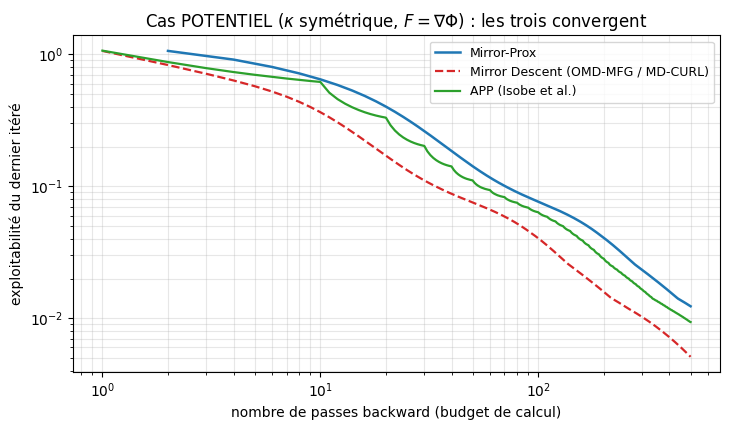

In [13]:
x_mp = 2 * np.arange(1, BUDGET // 2 + 1)      # 2 passes par iteration
x_md = np.arange(1, BUDGET + 1)
x_app = np.arange(1, len(app_pot[1]) + 1)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.loglog(x_mp, mp_pot[1], color='C0', lw=1.8, label='Mirror-Prox')
ax.loglog(x_md, md_pot[1], color='C3', ls='--', lw=1.6, label='Mirror Descent (OMD-MFG / MD-CURL)')
ax.loglog(x_app, app_pot[1], color='C2', lw=1.6, label='APP (Isobe et al.)')
ax.set_xlabel('nombre de passes backward (budget de calcul)')
ax.set_ylabel('exploitabilité du dernier itéré')
ax.set_title(r'Cas POTENTIEL ($\kappa$ symétrique, $F = \nabla\Phi$) : les trois convergent')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=.3)
fig.tight_layout(); plt.show()

Les trois algorithmes convergent, avec un léger avantage à **Mirror Descent** — logique : il est
le moins cher par itération, donc il en fait deux fois plus à budget égal, et l'extrapolation ne lui
manque pas sur un problème convexe. **Dans le cas potentiel, Mirror-Prox n'apporte rien.**

## 5. Expérience B — cas **non potentiel** : Mirror Descent casse

Même environnement, même budget — seul $\kappa$ change (partie antisymétrique $w = 5$).
L'opérateur reste **monotone** (Lasry-Lions vérifiée en section 1), donc toutes les hypothèses
(A.1)–(A.6) tiennent : c'est le même cadre théorique, mais **rotationnel**.

In [14]:
ex_np = make_exploit_fn(P_true, xi, reward_np, H)
mp_np = mirror_prox_mb(P_true, xi, reward_np, H, BUDGET // 2, gam)
md_np = mirror_descent_mb(P_true, xi, reward_np, H, BUDGET, gam)
app_np = app(P_true, xi, reward_np, H, BUDGET // TAU, TAU, LAM, ETA, ex_np)

drift_mp = np.abs(np.diff(mp_np[3], axis=0)).sum(2).max(1)
drift_md = np.abs(np.diff(md_np[3], axis=0)).sum(2).max(1)
print(f"NON POTENTIEL (budget {BUDGET} passes backward)")
print(f"  Mirror-Prox {mp_np[1][-1]:.3e} | Mirror-Descent {md_np[1][-1]:.3e} | APP {app_np[1][-1]:.3e}")
print(f"  dérive du flot (médiane, fin de run) : MP {np.median(drift_mp[-60:]):.2e}"
      f" | MD {np.median(drift_md[-60:]):.2e}")

NON POTENTIEL (budget 500 passes backward)
  Mirror-Prox 2.853e-02 | Mirror-Descent 9.002e-01 | APP 1.819e-02
  dérive du flot (médiane, fin de run) : MP 2.18e-03 | MD 2.02e-01


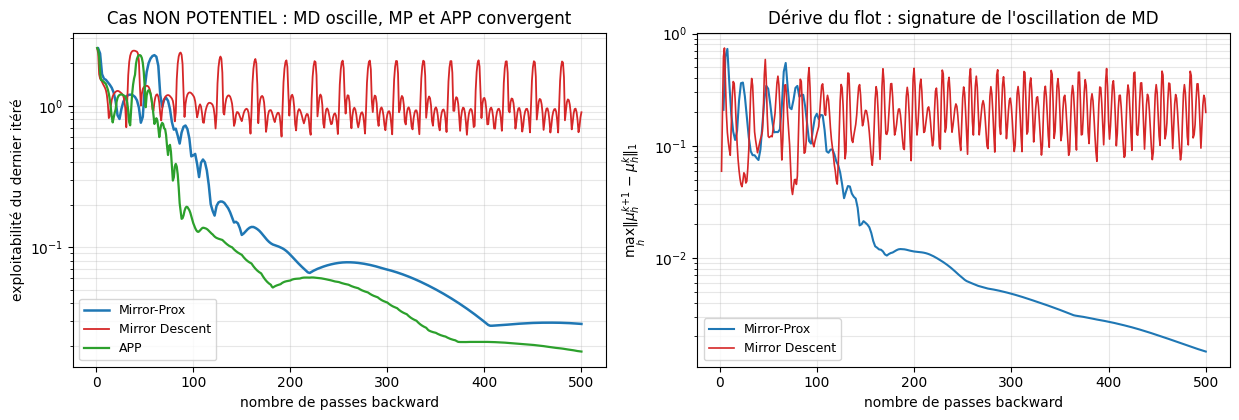

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
a1.semilogy(x_mp, mp_np[1], color='C0', lw=1.8, label='Mirror-Prox')
a1.semilogy(x_md, md_np[1], color='C3', lw=1.3, label='Mirror Descent')
a1.semilogy(np.arange(1, len(app_np[1]) + 1), app_np[1], color='C2', lw=1.6, label='APP')
a1.set_xlabel('nombre de passes backward'); a1.set_ylabel('exploitabilité du dernier itéré')
a1.set_title('Cas NON POTENTIEL : MD oscille, MP et APP convergent')
a1.legend(fontsize=9); a1.grid(True, which='both', alpha=.3)

a2.semilogy(x_mp[1:], drift_mp, color='C0', lw=1.5, label='Mirror-Prox')
a2.semilogy(x_md[1:], drift_md, color='C3', lw=1.2, label='Mirror Descent')
a2.set_xlabel('nombre de passes backward'); a2.set_ylabel(r'$\max_h \|\mu^{k+1}_h - \mu^k_h\|_1$')
a2.set_title("Dérive du flot : signature de l'oscillation de MD")
a2.legend(fontsize=9); a2.grid(True, which='both', alpha=.3)
fig.tight_layout(); plt.show()

**Deux enseignements, dont un inconfortable.**

1. **Mirror Descent casse bel et bien** : son exploitabilité stagne autour d'un plateau et la dérive
   du flot $\|\mu^{k+1}-\mu^k\|_1$ reste deux ordres de grandeur au-dessus de celle de MP — l'itéré
   *tourne en rond* autour de l'équilibre. C'est le comportement classique des méthodes du premier
   ordre sur les VI à composante antisymétrique, et ce que l'extrapolation est conçue pour amortir.

2. **APP converge aussi — et un peu mieux que Mirror-Prox.** C'est le résultat honnête : APP est
   spécifiquement conçu pour la convergence du dernier itéré sous monotonie non stricte, et il tient
   ses promesses sur ce banc d'essai. **Mirror-Prox ne domine donc pas l'état de l'art model-based**,
   il domine seulement la baseline naïve MD.

## 6. Diagramme de phase : dégradation progressive avec $w$

On fait varier l'intensité rotationnelle $w$ en gardant Lasry-Lions satisfaite partout.

In [16]:
w_grid = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
B_s = 300
res = {'MP': [], 'MD': [], 'APP': []}
for w in w_grid:
    kap = build_kappa(room, C_NP, w); rew = make_reward(kap, nA)
    exf = make_exploit_fn(P_true, xi, rew, H)
    _, e_mp, _, _ = mirror_prox_mb(P_true, xi, rew, H, B_s // 2, gam)
    _, e_md, _, _ = mirror_descent_mb(P_true, xi, rew, H, B_s, gam)
    _, e_app, _ = app(P_true, xi, rew, H, B_s // TAU, TAU, LAM, ETA, exf)
    res['MP'].append(e_mp[-20:].mean()); res['MD'].append(e_md[-20:].mean())
    res['APP'].append(e_app[-20:].mean())
    print(f"  w={w:.1f} | MP {res['MP'][-1]:.3e} | MD {res['MD'][-1]:.3e} | APP {res['APP'][-1]:.3e}")

  w=0.0 | MP 2.488e-02 | MD 1.291e-02 | APP 1.991e-02
  w=1.0 | MP 1.841e-01 | MD 1.729e-02 | APP 3.694e-02
  w=2.0 | MP 5.997e-02 | MD 2.392e-02 | APP 3.169e-02
  w=3.0 | MP 5.246e-02 | MD 2.131e-01 | APP 3.118e-02
  w=4.0 | MP 4.906e-02 | MD 6.199e-01 | APP 4.274e-02
  w=5.0 | MP 7.440e-02 | MD 1.080e+00 | APP 4.358e-02
  w=6.0 | MP 7.057e-02 | MD 1.499e+00 | APP 3.112e-02


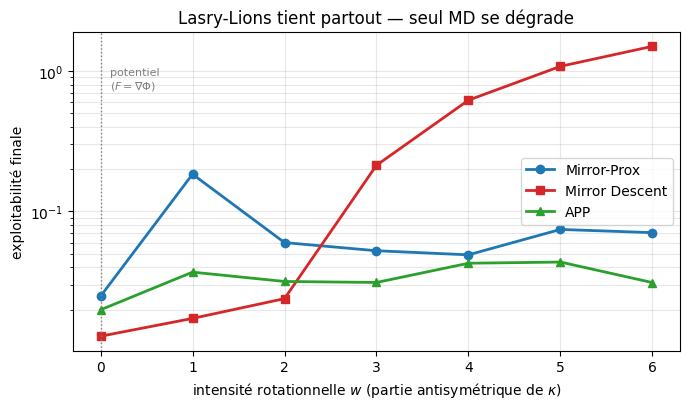

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(w_grid, res['MP'], 'o-', color='C0', lw=2, label='Mirror-Prox')
ax.semilogy(w_grid, res['MD'], 's-', color='C3', lw=2, label='Mirror Descent')
ax.semilogy(w_grid, res['APP'], '^-', color='C2', lw=2, label='APP')
ax.axvline(0, color='gray', ls=':', lw=1)
ax.text(0.1, max(res['MD']) * 0.5, 'potentiel\n($F=\\nabla\\Phi$)', fontsize=8, color='gray')
ax.set_xlabel(r"intensité rotationnelle $w$ (partie antisymétrique de $\kappa$)")
ax.set_ylabel('exploitabilité finale')
ax.set_title("Lasry-Lions tient partout — seul MD se dégrade")
ax.legend(); ax.grid(True, which='both', alpha=.3)
fig.tight_layout(); plt.show()

## 7. Sensibilité aux hyperparamètres : un avantage pratique de Mirror-Prox

Mirror-Prox n'a qu'**un** hyperparamètre ($\gamma$) ; APP en a **trois** ($\lambda$, $\eta$, $\tau$).
On balaie ici quelques réglages sur le cas non potentiel — dont celui utilisé dans les expériences
d'Isobe et al. ($\lambda = \eta = 0.1$).

In [18]:
configs = [(0.1, 0.1, 10), (0.1, 0.5, 10), (0.1, 1.0, 10), (0.05, 1.0, 10),
           (0.05, 2.0, 10), (0.02, 1.0, 10), (0.05, 1.0, 25)]
print("APP, cas non potentiel (budget 500 passes, moyenne des 20 derniers) :")
best_app = (None, 9e9)
for (lam, eta, tau) in configs:
    _, hist, _ = app(P_true, xi, reward_np, H, BUDGET // tau, tau, lam, eta, ex_np)
    tail = float(hist[-20:].mean())
    if tail < best_app[1]: best_app = ((lam, eta, tau), tail)
    flag = "   <-- réglage par défaut du papier" if (lam, eta) == (0.1, 0.1) else ""
    print(f"  lambda={lam:<5} eta={eta:<4} tau={tau:<3} -> {tail:.3e}{flag}")

print("\nMirror-Prox, même cas :")
best_mp = (None, 9e9)
for g in [0.5, 1.0, 2.0, 3.0, 4.0]:
    _, e, _, _ = mirror_prox_mb(P_true, xi, reward_np, H, BUDGET // 2, g)
    tail = float(e[-20:].mean())
    if tail < best_mp[1]: best_mp = (g, tail)
    print(f"  gamma={g:<4} -> {tail:.3e}")

print(f"\n>> À RÉGLAGE OPTIMAL : Mirror-Prox (gamma={best_mp[0]}) {best_mp[1]:.3e}"
      f"  |  APP {best_app[0]} {best_app[1]:.3e}")
print(f">> rapport APP / MP = {best_app[1] / best_mp[1]:.2f}")

APP, cas non potentiel (budget 500 passes, moyenne des 20 derniers) :
  lambda=0.1   eta=0.1  tau=10  -> 1.322e+00   <-- réglage par défaut du papier
  lambda=0.1   eta=0.5  tau=10  -> 5.664e-02
  lambda=0.1   eta=1.0  tau=10  -> 1.861e-02
  lambda=0.05  eta=1.0  tau=10  -> 1.740e-02
  lambda=0.05  eta=2.0  tau=10  -> 6.669e-01
  lambda=0.02  eta=1.0  tau=10  -> 6.052e-01
  lambda=0.05  eta=1.0  tau=25  -> 1.014e-01

Mirror-Prox, même cas :
  gamma=0.5  -> 8.424e-02
  gamma=1.0  -> 2.896e-02
  gamma=2.0  -> 1.136e-02
  gamma=3.0  -> 3.564e-01
  gamma=4.0  -> 7.155e-01

>> À RÉGLAGE OPTIMAL : Mirror-Prox (gamma=2.0) 1.136e-02  |  APP (0.05, 1.0, 10) 1.740e-02
>> rapport APP / MP = 1.53


**Trois observations.**

1. **Le réglage par défaut du papier d'origine** ($\lambda = \eta = 0.1$), calibré sur le *Beach Bar
   Process* où $r \in [0,1]$, **échoue sur notre banc d'essai** (récompenses de plus grande
   amplitude) : il faut re-régler $\eta$ d'un ordre de grandeur.

2. **À réglage optimal des deux, Mirror-Prox reprend l'avantage** — d'un facteur $\approx 1.5$
   seulement. La comparaison de la section 5, qui utilisait $\gamma = 1$, sous-estimait donc
   Mirror-Prox. La conclusion honnête est que **les deux algorithmes sont comparables**, sans
   domination nette.

3. **Les deux ont une fenêtre de stabilité étroite** : Mirror-Prox décroche pour $\gamma \geqslant 3$,
   APP pour $\eta \geqslant 2$. L'argument « Mirror-Prox est plus facile à régler » se limite donc au
   nombre de paramètres (un contre trois), pas à une plus grande tolérance sur chacun.

## 8. Le vrai terrain de Mirror-Prox : le cas **model-free**

C'est ici que la comparaison devient favorable, non pas par la performance mais par le **périmètre**.
Isobe et al. énoncent explicitement dans leurs limitations qu'ils se placent en model-based et ne
traitent ni l'apprentissage du modèle à partir de données, ni les garanties de complexité
d'échantillonnage nécessaires à une application model-free.

Greedy-OMP (notre version online de Mirror-Prox) s'attaque précisément à ce cadre : ni $P$ ni $r$ ne
sont connus, le noyau est estimé gloutonnement à partir des bruits observés. On vérifie ci-dessous
que la hiérarchie du cas model-based se transporte.

In [21]:
def _play_and_count(pi, h_true, xi, H, step_idx, M, rng, counts):
    nS, nA = step_idx.shape
    for _ in range(M):
        s = rng.choice(nS, p=xi)
        for h in range(H):
            a = rng.choice(nA, p=pi[h, s])
            e = rng.choice(nA + 1, p=h_true)
            counts[e] += 1
            s = step_idx[s, a] if e == nA else step_idx[s, e]

def greedy_online(step_idx, h_true, xi, reward, H, T, gam, algo='MP',
                  M=1, alpha_fn=lambda t: 1.0 / (t + 1), seed=0, mode='learn'):
    '''algo="MP" : Greedy-OMP  |  algo="MD" : Greedy-MD. mode="known" : oracle.'''
    nS, nA = step_idx.shape
    rng = np.random.default_rng(seed)
    P_t = kernel_from_noise(h_true, step_idx)
    counts = np.zeros(nA + 1)
    P_hat = P_t if mode == 'known' else kernel_from_noise(np.full(nA + 1, 1.0 / (nA + 1)), step_idx)
    pi_base = np.full((H, nS, nA), 1.0 / nA); pi_play = pi_base.copy()
    e_last, P_err = [], []
    for t in range(1, T + 1):
        _play_and_count(pi_play, h_true, xi, H, step_idx, M, rng, counts)
        if mode == 'learn':
            P_hat = kernel_from_noise(counts / counts.sum(), step_idx)
        a_t = alpha_fn(t)
        pi_tilde = (1.0 - a_t) * pi_base + a_t / nA
        d_tilde, _ = forward_unroll(pi_tilde, P_hat, xi, H)
        mu_t = H * d_tilde.sum(axis=2)
        if algo == 'MP':
            d_half = prox_gamma(mu_t, d_tilde, gam, P_hat, xi, reward)
            mu_half = H * d_half.sum(axis=2)
            d_full = prox_gamma(mu_half, d_tilde, gam, P_hat, xi, reward)
            pi_base, d_out = policy_of(d_full), d_half
        else:
            d_full = prox_gamma(mu_t, d_tilde, gam, P_hat, xi, reward)
            pi_base, d_out = policy_of(d_full), d_full
        pi_play = policy_of(d_out)
        d_pl, _ = forward_unroll(pi_play, P_t, xi, H)
        e_last.append(exploitability(d_pl, P_t, xi, reward))
        P_err.append(float(np.abs(P_hat - P_t).sum(axis=2).max()))
    return np.array(e_last), np.array(P_err)

T = 300
omp_np, perr = greedy_online(step_idx, h_true, xi, reward_np, H, T, gam, algo='MP', seed=0)
gmd_np, _    = greedy_online(step_idx, h_true, xi, reward_np, H, T, gam, algo='MD', seed=0)
omp_orc, _   = greedy_online(step_idx, h_true, xi, reward_np, H, T, gam, algo='MP', seed=1, mode='known')
omp_pot, _   = greedy_online(step_idx, h_true, xi, reward_pot, H, T, gam, algo='MP', seed=0)
gmd_pot, _   = greedy_online(step_idx, h_true, xi, reward_pot, H, T, gam, algo='MD', seed=0)
print(f"model-free, NON POTENTIEL | Greedy-OMP {omp_np[-1]:.3e} (vol. {omp_np[-50:].std():.3f})"
      f" | Greedy-MD {gmd_np[-1]:.3e} (vol. {gmd_np[-50:].std():.3f})")

model-free, NON POTENTIEL | Greedy-OMP 3.936e-02 (vol. 0.004) | Greedy-MD 3.851e-01 (vol. 0.102)


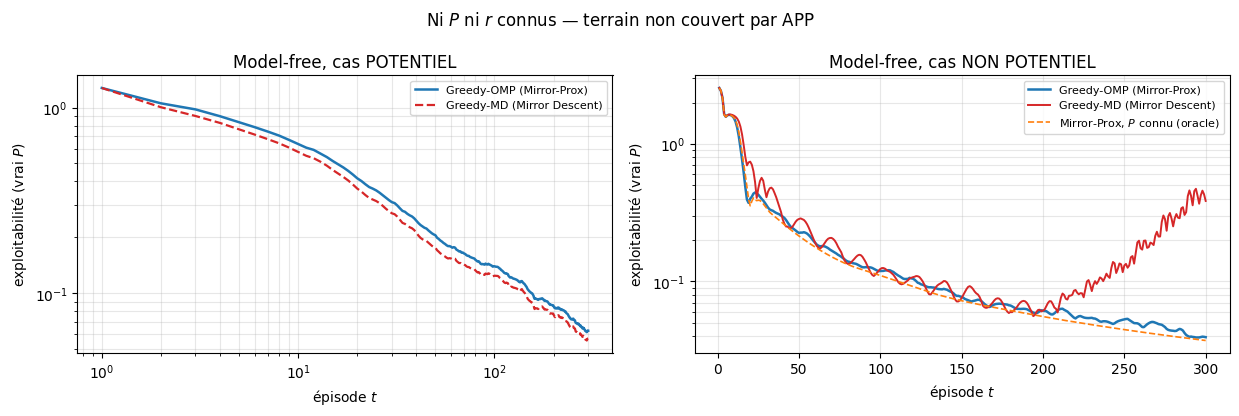

In [22]:
ts = np.arange(1, T + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
a1.loglog(ts, omp_pot, color='C0', lw=1.8, label='Greedy-OMP (Mirror-Prox)')
a1.loglog(ts, gmd_pot, color='C3', ls='--', lw=1.6, label='Greedy-MD (Mirror Descent)')
a1.set_xlabel('épisode $t$'); a1.set_ylabel('exploitabilité (vrai $P$)')
a1.set_title('Model-free, cas POTENTIEL'); a1.legend(fontsize=8); a1.grid(True, which='both', alpha=.3)

a2.semilogy(ts, omp_np, color='C0', lw=1.8, label='Greedy-OMP (Mirror-Prox)')
a2.semilogy(ts, gmd_np, color='C3', lw=1.4, label='Greedy-MD (Mirror Descent)')
a2.semilogy(ts, omp_orc, color='C1', ls='--', lw=1.2, label='Mirror-Prox, $P$ connu (oracle)')
a2.set_xlabel('épisode $t$'); a2.set_ylabel('exploitabilité (vrai $P$)')
a2.set_title('Model-free, cas NON POTENTIEL'); a2.legend(fontsize=8); a2.grid(True, which='both', alpha=.3)
fig.suptitle("Ni $P$ ni $r$ connus — terrain non couvert par APP")
fig.tight_layout(); plt.show()

Greedy-OMP décroît régulièrement et **rejoint l'oracle $P$ connu** (l'estimation gloutonne du
noyau coûte peu), alors que Greedy-MD, après une phase où le mixage $\alpha_t$ le stabilise
artificiellement, **repart en oscillation** quand $\alpha_t \to 0$.

**Note d'honnêteté :** rien n'interdit *a priori* de construire un « Greedy-APP » sur le même
protocole glouton. Nous ne l'avons pas fait, et l'affirmation ci-dessus porte donc sur ce qui existe
dans la littérature, pas sur une impossibilité. La difficulté prévisible est que la boucle interne
d'APP effectue $\tau$ évaluations de $Q$ par mise à jour de base, toutes sous le **même** modèle
estimé $\hat P^t$ : l'erreur de modèle s'y propagerait sans être rafraîchie par de nouvelles
observations.

## 9. Les deux équilibres

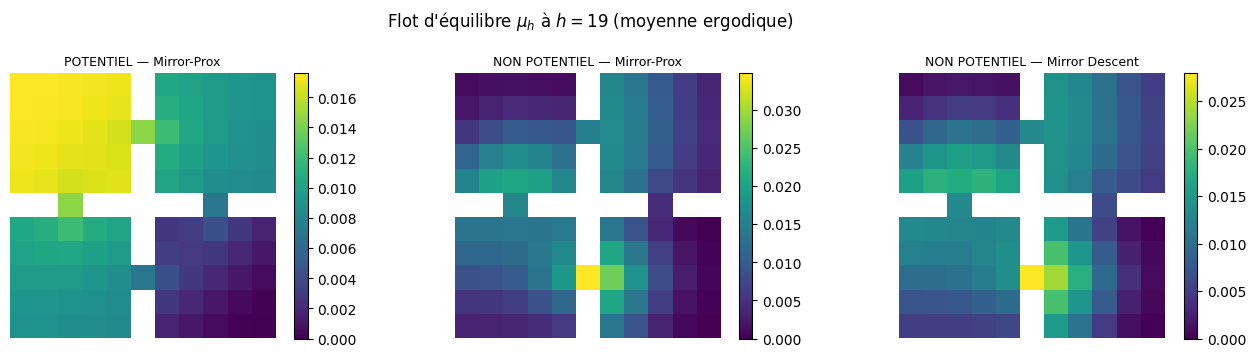

In [23]:
h_fix = H - 1
mu_pot_eq = H * mp_pot[0].sum(axis=2)
mu_np_eq  = H * mp_np[0].sum(axis=2)
mu_np_md  = H * md_np[0].sum(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, (mu, ttl) in zip(axes, [(mu_pot_eq, 'POTENTIEL — Mirror-Prox'),
                                (mu_np_eq, 'NON POTENTIEL — Mirror-Prox'),
                                (mu_np_md, 'NON POTENTIEL — Mirror Descent')]):
    im = ax.imshow(to_grid(mu[h_fix], coords, grid_shape), cmap='viridis')
    ax.set_title(ttl, fontsize=9); ax.axis('off'); fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Flot d'équilibre $\\mu_h$ à $h={h_fix}$ (moyenne ergodique)")
fig.tight_layout(); plt.show()

# Visualisation de l'explosion de l'exploitabilité sur la grille

### Modif de Greedy Online avec suivi du champ moyen

In [24]:
# --- copie de greedy_online + enregistrement du champ moyen joue a chaque episode ---
def greedy_online_rec(step_idx, h_true, xi, reward, H, T, gam, algo='MP',
                      M=1, alpha_fn=lambda t: 1.0 / (t + 1), seed=0, mode='learn'):
    '''Identique a greedy_online, mais renvoie AUSSI mus : (T, H, nS), le champ
       moyen joue (contre le vrai P) a chaque episode. Ne modifie rien d'existant.'''
    nS, nA = step_idx.shape
    rng = np.random.default_rng(seed)
    P_t = kernel_from_noise(h_true, step_idx)
    counts = np.zeros(nA + 1)
    P_hat = P_t if mode == 'known' else kernel_from_noise(np.full(nA + 1, 1.0 / (nA + 1)), step_idx)
    pi_base = np.full((H, nS, nA), 1.0 / nA); pi_play = pi_base.copy()
    e_last, mus = [], []
    for t in range(1, T + 1):
        _play_and_count(pi_play, h_true, xi, H, step_idx, M, rng, counts)
        if mode == 'learn':
            P_hat = kernel_from_noise(counts / counts.sum(), step_idx)
        a_t = alpha_fn(t)
        pi_tilde = (1.0 - a_t) * pi_base + a_t / nA
        d_tilde, _ = forward_unroll(pi_tilde, P_hat, xi, H)
        mu_t = H * d_tilde.sum(axis=2)
        if algo == 'MP':
            d_half = prox_gamma(mu_t, d_tilde, gam, P_hat, xi, reward)
            mu_half = H * d_half.sum(axis=2)
            d_full = prox_gamma(mu_half, d_tilde, gam, P_hat, xi, reward)
            pi_base, d_out = policy_of(d_full), d_half
        else:
            d_full = prox_gamma(mu_t, d_tilde, gam, P_hat, xi, reward)
            pi_base, d_out = policy_of(d_full), d_full
        pi_play = policy_of(d_out)
        d_pl, _ = forward_unroll(pi_play, P_t, xi, H)
        e_last.append(exploitability(d_pl, P_t, xi, reward))
        mus.append(H * d_pl.sum(axis=2))                 # <-- champ moyen joue
    return np.array(e_last), np.array(mus)

### Execution dans le cas non potentiel et model-free

In [25]:
T_rec = 300
e_md_r, mu_md_r = greedy_online_rec(step_idx, h_true, xi, reward_np, H, T_rec, gam, algo='MD', seed=0)
e_mp_r, mu_mp_r = greedy_online_rec(step_idx, h_true, xi, reward_np, H, T_rec, gam, algo='MP', seed=0)

t_ref = int(e_md_r.argmin()) + 1     # episode du minimum d'exploitabilite de MD
print(f"MD : minimum expl={e_md_r.min():.3e} a t={t_ref}, puis remonte a {e_md_r[-1]:.3e} a t={T_rec}")
print(f"MP : reste a {e_mp_r[-1]:.3e}")

MD : minimum expl=5.599e-02 a t=194, puis remonte a 3.851e-01 a t=300
MP : reste a 3.936e-02


### Visualisation : explosion sur la grille + comparaison avec Mirror-Prox

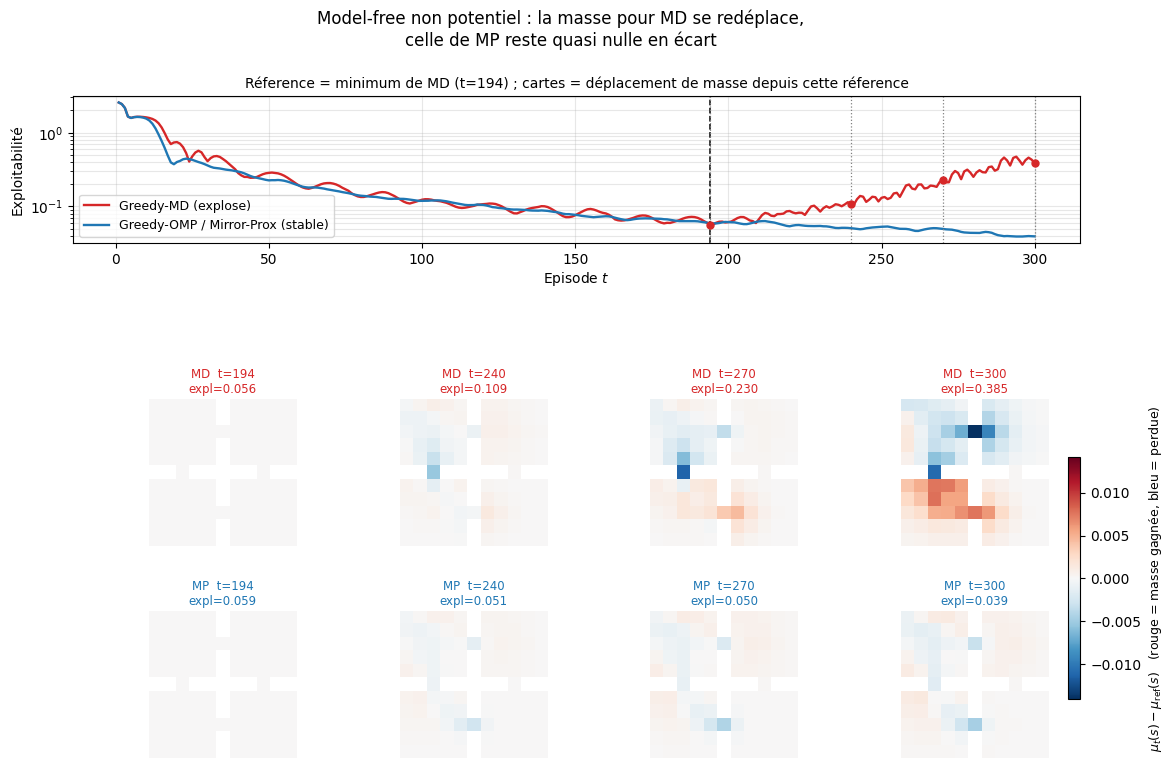

In [30]:
episodes = [t_ref, 240, 270, 300]                      # reference puis explosion
mu_ref_md = mu_md_r[t_ref - 1].mean(axis=0)            # moyenne sur l'horizon h
mu_ref_mp = mu_mp_r[t_ref - 1].mean(axis=0)

diffs_md = [mu_md_r[t - 1].mean(axis=0) - mu_ref_md for t in episodes]
diffs_mp = [mu_mp_r[t - 1].mean(axis=0) - mu_ref_mp for t in episodes]
amp = max(np.abs(np.array(diffs_md + diffs_mp)).max(), 1e-9)  # echelle de couleur partagee

fig = plt.figure(figsize=(13, 8.6))
# une ligne "fantome" (height ratio faible) separe la courbe des grilles ; hspace augmente
gs = fig.add_gridspec(4, 4, height_ratios=[1.0, 0.18, 1.0, 1.0], hspace=0.55, wspace=0.12)

# courbe en haut, avec reperes
axc = fig.add_subplot(gs[0, :])
ts = np.arange(1, T_rec + 1)
axc.semilogy(ts, e_md_r, color='C3', lw=1.7, label='Greedy-MD (explose)')
axc.semilogy(ts, e_mp_r, color='C0', lw=1.7, label='Greedy-OMP / Mirror-Prox (stable)')
axc.axvline(t_ref, color='k', ls='--', lw=1.1)
for t in episodes:
    axc.axvline(t, color='gray', ls=':', lw=0.9)
    axc.plot(t, e_md_r[t - 1], 'o', color='C3', ms=5, zorder=5)
axc.set_xlabel('Episode $t$', labelpad=2); axc.set_ylabel('Exploitabilité')
axc.grid(True, which='both', alpha=.3)
axc.legend(fontsize=9, loc='lower left')
axc.set_title(f"Réference = minimum de MD (t={t_ref}) ; cartes = déplacement de masse depuis cette réference",
              fontsize=10, pad=6)

# ligne du milieu : MD (l'explosion)  -> gs[2, :]
for j, t in enumerate(episodes):
    ax = fig.add_subplot(gs[2, j])
    im = ax.imshow(to_grid(diffs_md[j], coords, grid_shape), cmap='RdBu_r', vmin=-amp, vmax=amp)
    ax.set_title(f'MD  t={t}\nexpl={e_md_r[t-1]:.3f}', fontsize=8.5, color='C3', pad=4); ax.axis('off')

# ligne du bas : MP (le temoin stable)  -> gs[3, :]
for j, t in enumerate(episodes):
    ax = fig.add_subplot(gs[3, j])
    im = ax.imshow(to_grid(diffs_mp[j], coords, grid_shape), cmap='RdBu_r', vmin=-amp, vmax=amp)
    ax.set_title(f'MP  t={t}\nexpl={e_mp_r[t-1]:.3f}', fontsize=8.5, color='C0', pad=4); ax.axis('off')

# barre de couleur : seulement les axes des grilles (on saute la courbe et la ligne fantome)
grid_axes = fig.axes[1:]
cb = fig.colorbar(im, ax=grid_axes, fraction=0.012, pad=0.02)
cb.set_label(r'$\mu_t(s)-\mu_{\mathrm{ref}}(s)$   (rouge = masse gagnée, bleu = perdue)', fontsize=9)

fig.suptitle("Model-free non potentiel : la masse pour MD se redéplace,\n"
             "celle de MP reste quasi nulle en écart",
             y=0.98, fontsize=12)
plt.show()

## 10. Bilan — ce que ce notebook établit, et ce qu'il n'établit pas

**Établi :**

1. **Cas potentiel** ($\kappa$ symétrique) : les trois algorithmes convergent, avec un léger avantage
   à Mirror Descent (le moins cher). L'équivalence MFG–CURL s'applique, le problème est convexe :
   **Mirror-Prox n'apporte rien**. Les bancs d'essai de congestion classiques ne peuvent donc pas
   justifier l'algorithme.

2. **Cas non potentiel** ($\kappa$ à partie antisymétrique, Lasry-Lions toujours satisfaite) :
   **Mirror Descent oscille indéfiniment** — exploitabilité en plateau, dérive du flot deux ordres
   de grandeur au-dessus. Le diagramme de phase montre une dégradation **continue** avec $w$.
   La marge de généralité « monotone mais non potentiel » revendiquée dans la théorie n'est donc
   **pas vide**, et c'est bien la non-potentialité qui discrimine.

3. **Mirror-Prox y converge**, ce qui valide l'usage de l'extrapolation.

**Non établi (et il faut le dire) :**

4. **Mirror-Prox ne domine pas l'état de l'art model-based.** APP d'Isobe, Abe & Ariu converge lui
   aussi dans le cas non potentiel — c'est cohérent avec leur théorie, puisqu'APP est précisément
   conçu pour la convergence du dernier itéré sous monotonie **non stricte**. À réglage optimal des
   deux, Mirror-Prox garde un avantage d'un facteur $\approx 1.5$ (section 7), ce qui est trop
   faible pour conclure à une supériorité : **les deux méthodes sont comparables**. Le seul avantage
   net de Mirror-Prox est le **nombre d'hyperparamètres** (un contre trois).

**Où se situe alors la contribution ?** Sur le **périmètre**, pas sur la performance model-based :
Isobe et al. listent explicitement le cadre model-free et les garanties statistiques parmi leurs
limitations. Greedy-OMP, puis les versions MetaCURL, attaquent ce terrain — apprentissage du noyau
sans exploration, garanties de regret, et à terme le cas $P$ dépendant de $\mu$. C'est ainsi qu'il
faut positionner le travail : **non pas « un meilleur algorithme d'équilibre », mais « le passage à
l'online d'une méthode d'équilibre robuste au non potentiel »**.

**Suites naturelles.** (i) Implémenter un « Greedy-APP » pour vérifier si l'avantage d'APP survit à
l'estimation du modèle — c'est le test qui trancherait vraiment. (ii) Balayer d'autres structures
antisymétriques. (iii) Le cas $P[\mu]$, verrou commun aux deux approches (leur remarque 2.2 l'exclut
également).